# Day 2: Scikit-learn 回归模型基础

今天的目标：

- 理解监督学习中的 `X`、`y`、`model`、`y_pred`。
- 学会划分训练集和测试集。
- 用 Scikit-learn 训练线性回归和随机森林回归模型。
- 学会计算 MAE、RMSE、R2。
- 画出真实值 vs 预测值图。

今天仍然使用 Day 1 的小型材料数据。这个数据集很小，所以模型结果不能代表真实科研结论；它的作用是帮你理解机器学习流程。


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "../.matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists(): # 当前目录下没有​ data 文件夹 并且 上一级目录下有​ data 文件夹 则 将 PROJECT_ROOT 设置为上一级目录
    PROJECT_ROOT = PROJECT_ROOT.parent  

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/桌面/ai—study/day03


## 1. 读取 Day 1 的材料数据

在真实材料机器学习项目中，每一行通常表示一个材料，每一列是材料的属性、描述符或目标性质。


In [2]:
data_path = RAW_DATA_DIR / "day1_example_materials.csv"
df = pd.read_csv(data_path)
df


,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
0,Si,1.12,1,0,diamond
1,Ge,0.67,1,0,diamond
2,GaAs,1.42,2,0,zincblende
3,TiO2,3.20,2,1,rutile
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
6,Fe,0.00,1,0,bcc
7,Cu,0.00,1,0,fcc
8,MoS2,1.80,2,0,layered
9,SnO2,3.60,2,1,rutile


## 2. 定义特征 X 和标签 y

对带隙预测来说：

- `X` 是输入特征，也就是模型用来做判断的信息。
- `y` 是预测目标，也就是带隙 `band_gap_eV`。

这里先用两个非常粗糙的特征：

- `n_elements`：元素种类数。
- `contains_oxygen`：是否含氧。

这两个特征太简单，真实项目中肯定不够，但适合 Day 2 理解流程。


In [3]:
feature_cols = ["n_elements", "contains_oxygen"]
target_col = "band_gap_eV"

X = df[feature_cols]
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (10, 2)
y shape: (10,)


,n_elements,contains_oxygen
0,1,0
1,1,0
2,2,0
3,2,1
4,2,1


In [4]:
y.head()


0    1.12
1    0.67
2    1.42
3    3.20
4    3.37
Name: band_gap_eV, dtype: float64

## 3. 划分训练集和测试集

不能只在训练数据上评估模型。否则模型可能只是“记住了答案”，并不是真的学会了规律。

- 训练集：用来训练模型。
- 测试集：训练时不让模型看到，用来模拟新材料预测。


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)  # test_size=0.3 表示测试集占总数据集的30%，random_state=42 是随机种子，保证每次划分的数据集相同

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7, 2)
X_test shape: (3, 2)
y_train shape: (7,)
y_test shape: (3,)


## 4. 训练第一个模型：线性回归

线性回归会尝试学习一个类似下面的关系：

```text
band_gap = a * n_elements + b * contains_oxygen + c
```

这里的 `a`、`b`、`c` 是模型从数据中学到的参数。


In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
linear_pred


array([1.42      , 0.37333333, 3.39      ])

In [7]:
import sklearn
print(sklearn.__version__)

1.7.2


## 5. 评价模型

常用回归指标：

- MAE：平均绝对误差，单位和目标值相同，这里是 eV。
- RMSE：均方根误差，对大误差更敏感，单位也是 eV。
- R2：拟合优度，越接近 1 通常越好；数据很少时可能为负。


In [8]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

linear_metrics = evaluate_regression(y_test, linear_pred)
linear_metrics


{'MAE': 2.028888888888889,
 'RMSE': 3.135841785502532,
 'R2': 0.23950637228196248}

## 6. 训练第二个模型：随机森林

随机森林是由多棵决策树组成的模型。它能学习非线性关系，通常比线性回归更灵活。

但数据很少时，随机森林也可能不稳定，所以这里仍然只把它当作流程练习。


In [9]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_metrics = evaluate_regression(y_test, rf_pred)
rf_metrics


{'MAE': 2.0270072222222226,
 'RMSE': 3.1601335784631894,
 'R2': 0.22767841126116828}

## 7. 对比模型结果


In [10]:
metrics_df = pd.DataFrame([
    {"model": "Linear Regression", **linear_metrics},
    {"model": "Random Forest", **rf_metrics},
])

metrics_df


,model,MAE,RMSE,R2
0,Linear Regression,2.028889,3.135842,0.239506
1,Random Forest,2.027007,3.160134,0.227678


In [11]:
metrics_path = PROJECT_ROOT / "results" / "day2_model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
metrics_path


PosixPath('/mnt/d/桌面/ai—study/day03/results/day2_model_metrics.csv')

## 8. 保存测试集预测结果

对科研项目来说，只保存指标还不够。你还应该保存每个测试样本的真实值和预测值，方便后面做误差分析。


In [12]:
prediction_df = X_test.copy()
prediction_df["y_true"] = y_test.values
prediction_df["linear_pred"] = linear_pred
prediction_df["rf_pred"] = rf_pred
prediction_df


,n_elements,contains_oxygen,y_true,linear_pred,rf_pred
8,2,0,1.80,1.420000,1.426677
1,1,0,0.67,0.373333,0.417213
5,2,1,8.80,3.390000,3.345088


In [13]:
prediction_path = PROJECT_ROOT / "results" / "day2_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)
prediction_path


PosixPath('/mnt/d/桌面/ai—study/day03/results/day2_predictions.csv')

## 9. 画图：真实值 vs 预测值

理想情况下，点应该靠近对角线 `y = x`。点偏离越大，说明预测误差越大。


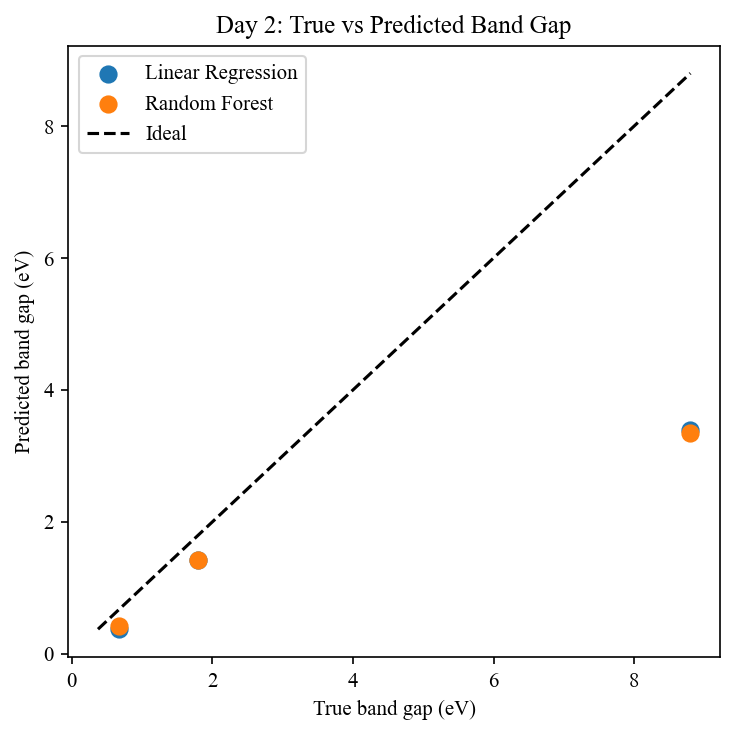

In [14]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
ax.scatter(y_test, linear_pred, label="Linear Regression", s=60)
ax.scatter(y_test, rf_pred, label="Random Forest", s=60)

min_value = min(y_test.min(), linear_pred.min(), rf_pred.min())
max_value = max(y_test.max(), linear_pred.max(), rf_pred.max())
ax.plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--", label="Ideal")

ax.set_xlabel("True band gap (eV)")
ax.set_ylabel("Predicted band gap (eV)")
ax.set_title("Day 2: True vs Predicted Band Gap")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day2_true_vs_predicted.png", dpi=300)
plt.show()


## 10. 今日练习

请你自己完成下面几个练习：

1. 把 `test_size` 从 `0.3` 改成 `0.4`，重新训练两个模型，观察指标是否变化。
2. 新增一个特征 `is_binary_compound`，当 `n_elements == 2` 时为 1，否则为 0。
3. 使用三个特征重新训练模型：`n_elements`、`contains_oxygen`、`is_binary_compound`。
4. 写一句话解释：为什么这个小数据集上的 R2 可能不稳定？
5. 保存新的模型对比结果到 `results/day2_model_metrics_with_binary_feature.csv`。

提示：第 2 题可以这样写：

```python
df["is_binary_compound"] = (df["n_elements"] == 2).astype(int)
```


In [21]:
# 练习 1：把 test_size 改成 0.4，重新划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_metrics = evaluate_regression(y_test, linear_pred)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_metrics = evaluate_regression(y_test, rf_pred)
print("Linear Regression metrics:", linear_metrics)
print("Random Forest metrics:", rf_metrics)
print(linear_pred)

Linear Regression metrics: {'MAE': 1.8950000000000005, 'RMSE': 2.7890769082260896, 'R2': 0.2929074980215439}
Random Forest metrics: {'MAE': 1.7630291666666675, 'RMSE': 2.7958428238164816, 'R2': 0.2894727193059363}
[ 1.42000000e+00 -1.11022302e-16  3.39000000e+00 -1.11022302e-16]


In [16]:
# 练习 2：新增 is_binary_compound 特征
df["is_binary_compound"] = df["n_elements"].apply(lambda x: 1 if x == 2 else 0)
df.head()

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type,is_binary_compound
0,Si,1.12,1,0,diamond,0
1,Ge,0.67,1,0,diamond,0
2,GaAs,1.42,2,0,zincblende,1
3,TiO2,3.20,2,1,rutile,1
4,ZnO,3.37,2,1,wurtzite,1


In [17]:
# 练习 3：使用三个特征重新训练 Linear Regression 和 Random Forest
feature_cols = ["n_elements", "contains_oxygen", "is_binary_compound"]
X = df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_metrics = evaluate_regression(y_test, linear_pred)
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_metrics = evaluate_regression(y_test, rf_pred)
print("Linear Regression metrics:", linear_metrics)
print("Random Forest metrics:", rf_metrics)

Linear Regression metrics: {'MAE': 1.8950000000000005, 'RMSE': 2.7890769082260896, 'R2': 0.2929074980215439}
Random Forest metrics: {'MAE': 1.7630291666666675, 'RMSE': 2.7958428238164816, 'R2': 0.2894727193059363}


In [ ]:
# 练习 4：用你自己的话解释 R2 为什么可能不稳定

r2_explanation = """
这个数据集只有 10 个材料，测试集只有 4 个样本，样本数量太少。
当训练集/测试集划分稍微变化时，测试集中材料的带隙分布也会明显变化，
所以 R2 会很不稳定，甚至可能变成负数。
因此这个小数据集只能用于理解机器学习流程，不能用于判断真实模型性能。
"""
print(r2_explanation)


In [22]:
# 练习 5：保存新的模型对比结果
prediction_df = X_test.copy()
prediction_df["y_true"] = y_test.values
prediction_df["linear_pred"] = linear_pred
prediction_df["rf_pred"] = rf_pred
metric_df = pd.DataFrame([
    {"model": "Linear Regression", **linear_metrics},
    {"model": "Random Forest", **rf_metrics}
])
prediction_df.to_csv(PROJECT_ROOT / "results" / "day2_predictions_with_binary_features.csv", index=False)
metric_df.to_csv(PROJECT_ROOT / "results" / "day2_model_metrics_with_binary_features.csv", index=False)

## 11. 今日自查

完成 Day 2 后，请确认你能回答：

- `X` 是什么？
- `y` 是什么？
- `fit` 在做什么？
- `predict` 在做什么？
- 为什么要划分训练集和测试集？
- MAE 的单位是什么？
- RMSE 和 MAE 有什么区别？
- R2 可能为负数吗？
- 线性回归和随机森林有什么直观区别？
